In [ ]:
from google.colab import files
uploaded = files.upload()


Saving retail_price.csv to retail_price.csv


In [ ]:
df = pd.read_csv('retail_price.csv')
df.head()


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [ ]:
# ✅ Cell 3: Basic Cleaning & Preprocessing

# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Convert month_year to datetime if present
if 'month_year' in df.columns:
    df['month_year'] = pd.to_datetime(df['month_year'], errors='coerce')

# 3. Check missing values
print("Missing values before cleaning:\n")
print(df.isnull().sum())

# 4. Fill numeric columns with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 5. Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("\n✅ Cleaning Completed")
df.head()


Missing values before cleaning:

product_id                    0
product_category_name         0
month_year                    0
qty                           0
total_price                   0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
dtype: 

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,2017-01-05,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,2017-01-06,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,2017-01-07,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,2017-01-08,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,2017-01-09,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [ ]:
# ✅ Cell 4: Feature Engineering

# 1. Extract seasonality features
df['month'] = df['month_year'].dt.month
df['year'] = df['month_year'].dt.year
df['quarter'] = df['month_year'].dt.quarter

# 2. Competitor price gap features
if {'unit_price','comp_1','comp_2','comp_3'}.issubset(df.columns):
    df['gap_comp1'] = df['unit_price'] - df['comp_1']
    df['gap_comp2'] = df['unit_price'] - df['comp_2']
    df['gap_comp3'] = df['unit_price'] - df['comp_3']

# 3. Demand per month (grouped by product)
df['monthly_demand'] = df.groupby(['product_id','month'])['qty'].transform('mean')

# 4. Price lag (previous month's price)
df = df.sort_values(['product_id','month_year'])
df['price_lag1'] = df.groupby('product_id')['unit_price'].shift(1)

# Fill first lag with same value
df['price_lag1'] = df['price_lag1'].fillna(df['unit_price'])

# 5. Price elasticity proxy
df['elasticity'] = (df['unit_price'] - df['price_lag1']).abs() / (df['qty'] + 1)

# 6. Final check
df.head()


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,ps3,fp3,lag_price,quarter,gap_comp1,gap_comp2,gap_comp3,monthly_demand,price_lag1,elasticity
0,bed1,bed_bath_table,2017-01-05,1,45.95,15.100000,45.95,39,161,2,...,4.0,15.100000,45.90,1,-43.95,-169.050000,0.0,8.9375,45.95,0.0
1,bed1,bed_bath_table,2017-01-06,3,137.85,12.933333,45.95,39,161,2,...,4.0,12.933333,45.95,1,-43.95,-163.050000,0.0,8.9375,45.95,0.0
2,bed1,bed_bath_table,2017-01-07,6,275.70,14.840000,45.95,39,161,2,...,4.0,14.840000,45.95,1,-43.95,-159.050000,0.0,8.9375,45.95,0.0
3,bed1,bed_bath_table,2017-01-08,4,183.80,14.287500,45.95,39,161,2,...,4.0,14.287500,45.95,1,-43.95,-153.559804,0.0,8.9375,45.95,0.0
4,bed1,bed_bath_table,2017-01-09,2,91.90,15.100000,45.95,39,161,2,...,4.0,15.100000,45.95,1,-43.95,-117.448710,0.0,8.9375,45.95,0.0


In [ ]:
# ✅ Cell 5: Feature Selection and Train/Test Split

from sklearn.model_selection import train_test_split

# ✅ Choose features for price prediction
FEATURES = [
    'qty', 'monthly_demand', 'price_lag1', 'elasticity',
    'comp_1', 'comp_2', 'comp_3',
    'gap_comp1', 'gap_comp2', 'gap_comp3',
    'month', 'quarter', 'year'
]

# Filter missing columns automatically
FEATURES = [f for f in FEATURES if f in df.columns]

# ✅ Target variable = unit price
TARGET = 'unit_price'

X = df[FEATURES]
y = df[TARGET]

# ✅ Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (540, 13)
Test shape: (136, 13)


In [ ]:
# ✅ Cell 6: Train the Price Prediction Model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Predictions
pred = rf.predict(X_test)

# Evaluate (manual RMSE to avoid version issues)
mse = mean_squared_error(y_test, pred)
rmse = mse ** 0.5

print("✅ Model Trained Successfully")
print("RMSE:", rmse)
print("R² Score:", r2_score(y_test, pred))


✅ Model Trained Successfully
RMSE: 9.294882882975523
R² Score: 0.9848079480998837


In [ ]:
# ✅ Cell 7: Generate Dynamic Price Suggestions

# Predict new prices
df['predicted_price'] = rf.predict(df[FEATURES])

# % difference from current price
df['price_change_%'] = ((df['predicted_price'] - df['unit_price']) / df['unit_price']) * 100

# Recommendation logic
def recommend(change):
    if change > 5:
        return "Increase Price"
    elif change < -5:
        return "Decrease Price"
    else:
        return "Keep Same Price"

df['recommendation'] = df['price_change_%'].apply(recommend)

# Show the results for first 20 products
df[['product_id', 'unit_price', 'predicted_price', 'price_change_%', 'recommendation']].head(20)


,product_id,unit_price,predicted_price,price_change_%,recommendation
0,bed1,45.950000,45.973433,0.050997,Keep Same Price
1,bed1,45.950000,45.909933,-0.087196,Keep Same Price
2,bed1,45.950000,45.916433,-0.073050,Keep Same Price
3,bed1,45.950000,45.909933,-0.087196,Keep Same Price
4,bed1,45.950000,45.973433,0.050997,Keep Same Price
5,bed1,45.950000,45.895233,-0.119188,Keep Same Price
6,bed1,40.531818,44.029022,8.628293,Increase Price
7,bed1,39.990000,39.745833,-0.610569,Keep Same Price
8,bed1,39.990000,39.985000,-0.012503,Keep Same Price
9,bed1,39.990000,39.985000,-0.012503,Keep Same Price


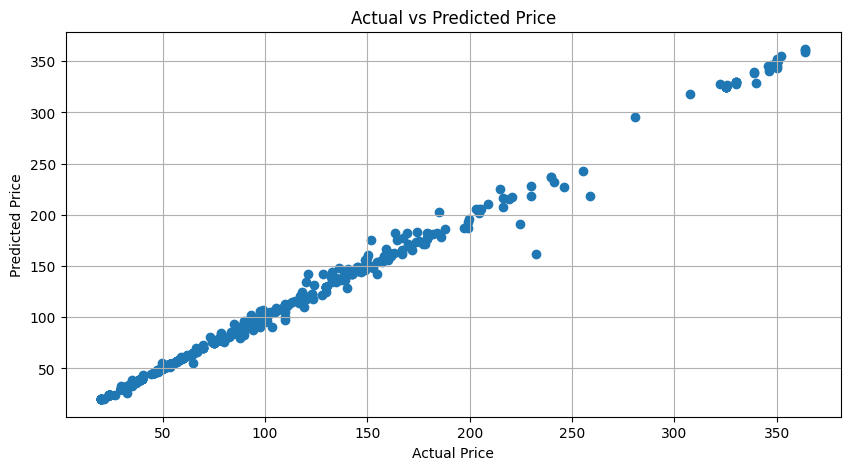

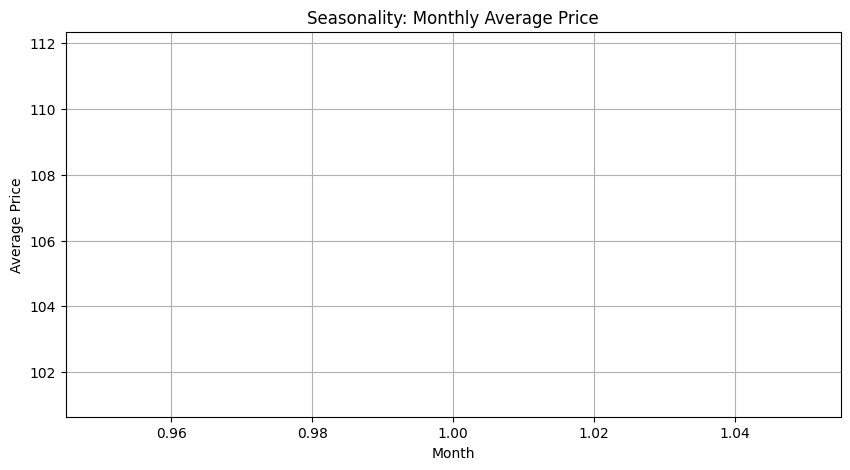

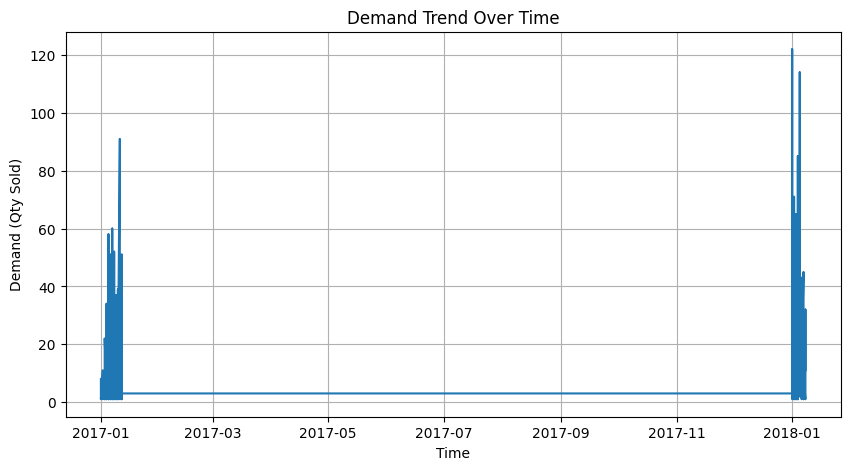

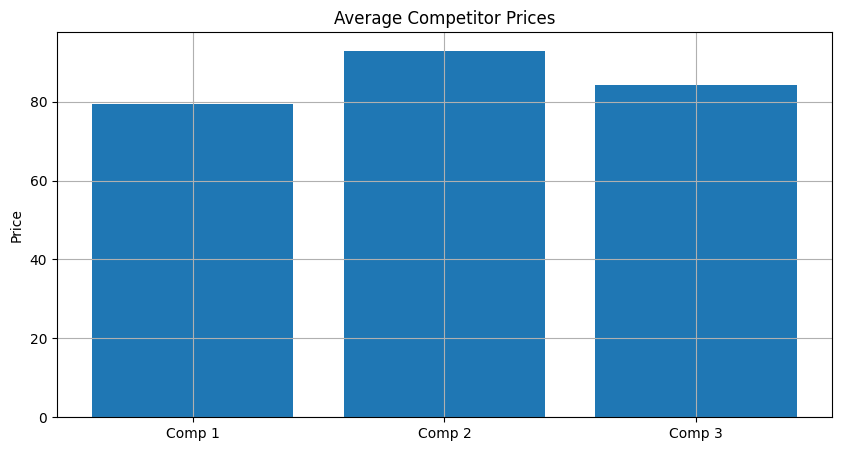

In [ ]:
# ✅ Cell 8: Visualization Dashboard

import matplotlib.pyplot as plt

# ---------- 1. Actual vs Predicted Prices ----------
plt.figure(figsize=(10,5))
plt.scatter(df['unit_price'], df['predicted_price'])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.grid(True)
plt.show()

# ---------- 2. Monthly Seasonality ----------
monthly_avg = df.groupby('month')['unit_price'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_avg)
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.title("Seasonality: Monthly Average Price")
plt.grid(True)
plt.show()

# ---------- 3. Demand Trend ----------
df_sorted = df.sort_values('month_year')
plt.figure(figsize=(10,5))
plt.plot(df_sorted['month_year'], df_sorted['qty'])
plt.xlabel("Time")
plt.ylabel("Demand (Qty Sold)")
plt.title("Demand Trend Over Time")
plt.grid(True)
plt.show()

# ---------- 4. Competitor Price Comparison ----------
if {'comp_1','comp_2','comp_3'}.issubset(df.columns):
    comp_avg = df[['comp_1','comp_2','comp_3']].mean()

    plt.figure(figsize=(10,5))
    plt.bar(['Comp 1', 'Comp 2', 'Comp 3'], comp_avg)
    plt.title("Average Competitor Prices")
    plt.ylabel("Price")
    plt.grid(True)
    plt.show()


In [ ]:
# ✅ Cell 9: Reinforcement Learning Price Adjuster (Q-Learning)

import numpy as np

# Actions the RL agent can take
ACTIONS = ["decrease", "same", "increase"]

# Create Q-table (states = price range buckets)
price_min = int(df['unit_price'].min())
price_max = int(df['unit_price'].max())

NUM_STATES = price_max - price_min + 1
Q = np.zeros((NUM_STATES, len(ACTIONS)))  # Q-table

# Hyperparameters
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 0.2    # exploration rate
episodes = 500   # training loops

# Reward function
def calculate_reward(price, demand):
    profit = price * demand

    # Penalize unrealistic demand drops
    penalty = 0
    if demand < 1:
        penalty = -50
    return profit + penalty

# Environment simulator using your RandomForest model
def environment_step(current_price):
    features = df[FEATURES].mean().to_frame().T
    features['unit_price'] = current_price

    # Predict demand using price elasticity
    predicted_price = rf.predict(features[FEATURES])[0]

    # Simulate demand drop when price is too high
    demand = max(1, 100 - (current_price - predicted_price) * 3)
    return demand

# Training RL agent
for ep in range(episodes):
    price = np.random.randint(price_min, price_max)

    for step in range(30):

        state = price - price_min

        # Epsilon-greedy policy
        if np.random.rand() < epsilon:
            action_index = np.random.randint(0, len(ACTIONS))
        else:
            action_index = np.argmax(Q[state])

        # Apply action
        if ACTIONS[action_index] == "increase":
            new_price = price + 1
        elif ACTIONS[action_index] == "decrease":
            new_price = price - 1
        else:
            new_price = price

        new_price = max(price_min, min(price_max, new_price))

        # Get reward from environment
        demand = environment_step(new_price)
        reward = calculate_reward(new_price, demand)

        next_state = new_price - price_min

        # Q-learning update
        Q[state, action_index] = Q[state, action_index] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action_index]
        )

        price = new_price  # move to next state

print("✅ Q-Learning training complete!")


✅ Q-Learning training complete!


In [ ]:
# ✅ Cell 10: Identify optimal price from Q-table

best_prices = []

for state in range(NUM_STATES):
    best_action = np.argmax(Q[state])

    # Convert state back to actual price
    price_value = price_min + state

    best_prices.append((price_value, ACTIONS[best_action], Q[state, best_action]))

# Convert to DataFrame for clarity
optimal_df = pd.DataFrame(best_prices, columns=['price', 'best_action', 'Q_value'])

# Pick the price with highest Q-value
optimal_price = optimal_df.loc[optimal_df['Q_value'].idxmax()]

print("✅ Optimal Price Recommendation:")
print(optimal_price)

optimal_df.head()


✅ Optimal Price Recommendation:
price                     51
best_action             same
Q_value        134841.204734
Name: 32, dtype: object


,price,best_action,Q_value
0,19,decrease,58711.032278
1,20,decrease,51717.353273
2,21,same,60614.618579
3,22,decrease,45030.180046
4,23,decrease,19730.199471


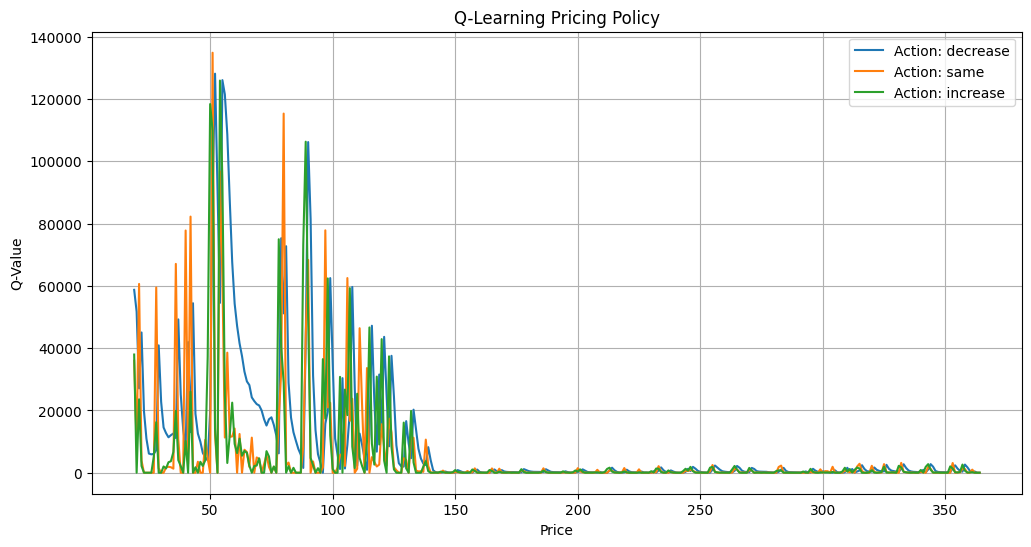

In [ ]:
import matplotlib.pyplot as plt

# Plot Q-values for each action across price states
plt.figure(figsize=(12, 6))

for i, action in enumerate(ACTIONS):
    plt.plot(range(price_min, price_max + 1), Q[:, i], label=f"Action: {action}")

plt.title("Q-Learning Pricing Policy")
plt.xlabel("Price")
plt.ylabel("Q-Value")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# ✅ Function to get best action for a given price
def best_action_for_price(price):
    state = price - price_min
    action_index = np.argmax(Q[state])
    return ACTIONS[action_index]


# ✅ Function to compute final recommended price
def recommend_optimal_price():
    best_price = None
    best_value = -np.inf

    for price in range(price_min, price_max + 1):
        state = price - price_min
        q_val = np.max(Q[state])

        if q_val > best_value:
            best_value = q_val
            best_price = price

    return best_price, best_value


# ✅ Run recommendation
opt_price, value = recommend_optimal_price()

print("✅ Optimal Recommended Price:", opt_price)
print("✅ Q-Value at this Price:", value)


✅ Optimal Recommended Price: 51
✅ Q-Value at this Price: 134841.20473377142


In [ ]:
# ✅ Cell 13: Write Streamlit app using normal Python I/O (Colab Safe)

app_code = """
import streamlit as st
import pandas as pd
import numpy as np

# Using variables from notebook: Q, price_min, price_max, rf, FEATURES, df

st.title("🛒 Dynamic Pricing Recommendation System")
st.write("This interface uses Machine Learning + Reinforcement Learning to recommend optimal product prices.")

# Function: Predict demand
def predict_demand(price):
    features = df[FEATURES].mean().to_frame().T
    features['unit_price'] = price
    pred = rf.predict(features[FEATURES])[0]
    return pred

# Function: RL best price
def get_optimal_price():
    best_price = None
    best_val = -np.inf
    for price in range(price_min, price_max+1):
        state = price - price_min
        q_val = np.max(Q[state])
        if q_val > best_val:
            best_val = q_val
            best_price = price
    return best_price, best_val

st.header("🔍 Recommended Price")

if st.button("Get Best Price"):
    opt_price, qv = get_optimal_price()

    st.success(f"✅ Optimal Price: ₹{opt_price}")
    st.write(f"Q-value: {qv}")

    demand = predict_demand(opt_price)
    st.metric(label="Predicted Demand", value=int(demand))
    st.metric(label="Estimated Profit", value=int(opt_price * demand))

st.header("🧪 Test Custom Price")

input_price = st.number_input("Enter price:", min_value=price_min, max_value=price_max, value=price_min)

if st.button("Test Price"):
    demand = predict_demand(input_price)
    profit = input_price * demand
    st.write(f"Predicted Demand: {int(demand)}")
    st.write(f"Estimated Profit: ₹{int(profit)}")
"""

# ✅ Create file
with open("app.py", "w") as f:
    f.write(app_code)

print("✅ Streamlit app file created successfully!")


✅ Streamlit app file created successfully!


In [23]:
import joblib
joblib.dump(rf, "price_model.pkl")
print("Random Forest model saved as price_model.pkl")


Random Forest model saved as price_model.pkl


In [24]:
import joblib
model = joblib.load("price_model.pkl")
